# Imports & Helper

In [4]:
import torch

# DTYPE = torch.float16
DTYPE = torch.float32

if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

print(f"Using device: {device}")

from diffusers import AutoencoderKL

vae32 = AutoencoderKL.from_pretrained(
    "black-forest-labs/FLUX.1-dev",
    subfolder="vae"    
).to(device)  

Using device: cuda


In [5]:
import numpy as np
import torch.nn.functional as F

def resize_crop_latent(image: torch.Tensor, K: np.ndarray, patch_size: int = 32, vae_scale=8):
    """
    Resize/crop a latent tensor (C,H,W) or (1,C,H,W) with subpixel accuracy.
    """
    if image.ndim == 3:
        image = image.unsqueeze(0)  # (1,C,H,W)

    _, _, h, w = image.shape
    scale = patch_size / min(h, w)
    new_w, new_h = w * scale, h * scale
    crop_x = (new_w - patch_size) / 2
    crop_y = (new_h - patch_size) / 2

    # Affine transform normalized to [-1,1]
    M = np.array([[scale, 0, -crop_x],
                  [0, scale, -crop_y]], dtype=np.float32)
    theta = torch.tensor(M, dtype=torch.float32, device=image.device).unsqueeze(0)
    grid = F.affine_grid(theta, size=(1, image.shape[1], patch_size, patch_size), align_corners=False)
    cropped_resized = F.grid_sample(image, grid, mode='bilinear', align_corners=False)

    # Adjust K for scale/crop and latent scale
    K_scaled = K.copy()
    K_scaled[:2, :] *= scale / vae_scale
    K_scaled[0, 2] -= crop_x / vae_scale
    K_scaled[1, 2] -= crop_y / vae_scale

    return cropped_resized.squeeze(0), K_scaled

In [6]:
import torch
import matplotlib.pyplot as plt

def show_tensor(tensor, title=None):
    """
    Display a single image tensor using matplotlib.
    Works for:
      - [3, H, W] RGB tensors
      - [1, H, W] grayscale tensors
      - [B, 3, H, W] -> shows the first image in the batch

    Args:
        tensor (torch.Tensor): Image tensor to display.
        title (str, optional): Optional title for the plot.
    """
    # Move to CPU and detach from graph
    tensor = tensor.detach().cpu()

    # Handle batch dimension
    if tensor.dim() == 4:
        tensor = tensor[0]

    # If normalized to [-1, 1], convert back to [0, 1]
    if tensor.min() < 0:
        tensor = (tensor + 1) / 2

    # Clamp to [0, 1] just in case
    tensor = tensor.clamp(0, 1)

    # Convert from (C, H, W) → (H, W, C)
    if tensor.shape[0] == 3:
        img = tensor.permute(1, 2, 0).numpy()
        plt.imshow(img)
    elif tensor.shape[0] == 1:
        img = tensor.squeeze(0).numpy()
        plt.imshow(img, cmap="gray")
    else:
        raise ValueError(f"Unsupported tensor shape: {tensor.shape}")

    plt.axis("off")
    if title:
        plt.title(title)
    plt.show()

In [63]:
def draw_grid(
    img,
    cells=8,
    thickness=1,
    value=1.0,
    alpha=1.0,
    highlight_x=None,
    highlight_y=None
):
    """
    Draws a grid and optionally outlines one cell in red.

    Args:
        img: torch.Tensor [N, 3, H, W]
        cells: number of cells along each axis
        thickness: grid line thickness in pixels
        value: grid line color value (white=1.0 if image normalized)
        alpha: blend factor for grid lines (1.0 = overwrite)
        highlight_x, highlight_y: integer indices (0–cells-1)
            specifying the cell to outline in red
    """
    assert img.dim() == 4 and img.size(1) == 3, "Expected NCHW with 3 channels"
    N, C, H, W = img.shape
    step_h = H // cells
    step_w = W // cells

    ys = torch.arange(H, device=img.device).view(H, 1)
    xs = torch.arange(W, device=img.device).view(1, W)

    # --- Base grid mask (white lines) ---
    mask_h = (ys % step_h) < thickness
    mask_w = (xs % step_w) < thickness
    grid_mask = (mask_h | mask_w).unsqueeze(0).unsqueeze(0)  # [1,1,H,W]

    out = img.clone()
    if alpha >= 1.0:
        out = torch.where(grid_mask, value, out)
    else:
        a = alpha * grid_mask.to(out.dtype)
        out = out * (1 - a) + value * a

    # --- Highlight cell outline in red ---
    if highlight_x is not None and highlight_y is not None:
        y0 = highlight_y * step_h
        y1 = (highlight_y + 1) * step_h
        x0 = highlight_x * step_w
        x1 = (highlight_x + 1) * step_w

        # Outline mask for that cell
        highlight_mask = torch.zeros((H, W), dtype=torch.bool, device=img.device)
        highlight_mask[y0:y0 + thickness, x0:x1] = True   # top edge
        highlight_mask[y1 - thickness:y1, x0:x1] = True   # bottom edge
        highlight_mask[y0:y1, x0:x0 + thickness] = True   # left edge
        highlight_mask[y0:y1, x1 - thickness:x1] = True   # right edge
        highlight_mask = highlight_mask.unsqueeze(0).unsqueeze(0)

        # Red color (1, 0, 0)
        red = torch.tensor([1.0, 0.0, 0.0], device=img.device).view(1, 3, 1, 1)

        out = torch.where(highlight_mask, red, out)

    return out

# Load Test Dataset Samples

/tmp/ipykernel_31538/2288935575.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  image_pre = torch.load(abs_image_path)


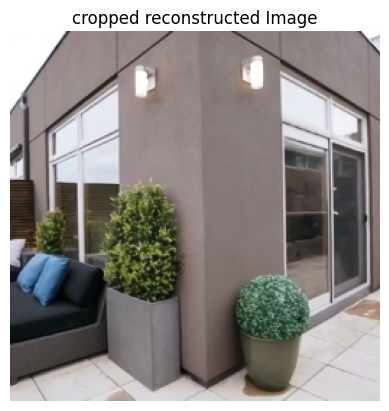

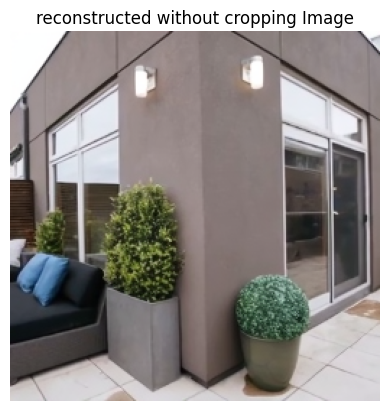

In [213]:
# create test dataset loading
abs_image_path = f"../data_processed/realestate10k_latent/train/0c6c060f599465ed/images/59959900.pt"
image_pre = torch.load(abs_image_path)
K = np.eye(3)
image, K = resize_crop_latent(image_pre, K)

image = image.permute(1, 2, 0) # [C,W,H] → [W,H,C]
image = image.permute(2, 0, 1).unsqueeze(0).to(device) # [W,H,C] → [1,C,W,H]            

# image_pre.shape = torch.Size([1, 16, 45, 80])
# image.shape     = torch.Size([1, 16, 32, 32])

with torch.no_grad():    
    image_pre_reconstructed = vae32.decode(image_pre.float().to(device)).sample
    image_reconstructed = vae32.decode(image.float()).sample

show_tensor(image_reconstructed.float(), title="cropped reconstructed Image")
show_tensor(image_pre_reconstructed.float(), title="reconstructed without cropping Image")


# Load individual tensors

/tmp/ipykernel_1091/1512498198.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  original_t = torch.load(f"../results/nvs_vae/{result_path}/visuals/gt.pt").squeeze().to(d

tensor([[-0.0781, -2.9757,  1.0960,  1.6231,  0.4065, -0.2842, -1.4391,  0.6788,
         -3.6120, -0.6310,  0.0810, -1.6114, -1.6407,  0.8945, -1.2567,  2.3239]],
       device='cuda:0')
tensor([[-0.5859, -2.1855, -0.2578, -0.5332,  0.5156,  0.3398, -3.5684,  1.9219,
         -1.4062,  0.2109,  0.2812, -1.9453, -1.1250,  1.6406,  0.3516,  0.5391]],
       device='cuda:0', dtype=torch.float16, grad_fn=<SelectBackward0>)


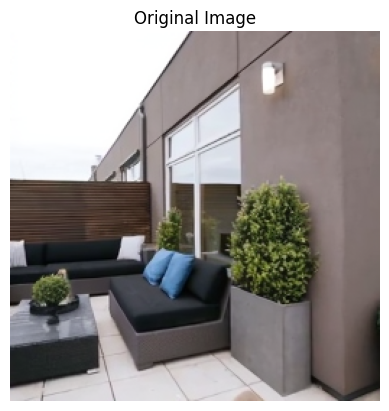

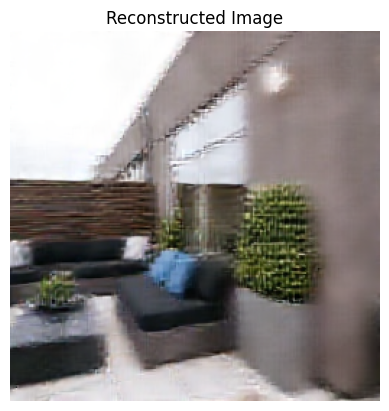

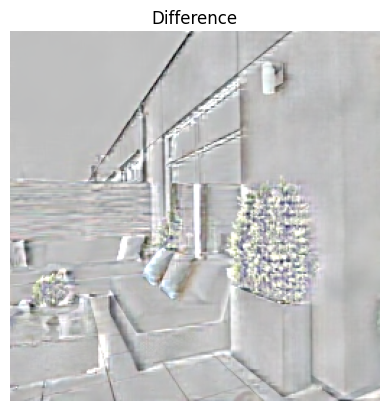

In [117]:
LATENT_MEAN = 0.5
LATENT_STD = 0.163

def denormalize_latent_static(z_mapped: torch.Tensor) -> torch.Tensor:
    # z_mapped = z_mapped * LATENT_STD + LATENT_MEAN
    z_orig = (z_mapped - 0.5) * 24    
    return z_orig


# preprocessed data (convert_to_latent.py)
# this works
# original_t = torch.load("../data_processed/realestate10k_latent/train/0c6c060f599465ed/images/59959900.pt").to(device)
# torch.Size([1, 16, 32, 32])
# → 16 latent channels


result_path = "release-1gpus-b8-s1-80k-camray-prope"
# result_path = "release-1gpus-b8-s1-80k-plucker-none"

# gt data within training
# this works
original_t = torch.load(f"../results/nvs_vae/{result_path}/visuals/gt.pt").squeeze().to(device)
original_t = original_t.unsqueeze(0).permute(0,3,1,2)
original_t = denormalize_latent_static(original_t)

reconstructed_t = torch.load(f"../results/nvs_vae/{result_path}/visuals/outputs.pt").squeeze().to(device)
reconstructed_t = reconstructed_t.unsqueeze(0).permute(0,3,1,2)
reconstructed_t = denormalize_latent_static(reconstructed_t)

# original_t = original_t.permute(2, 0, 1).unsqueeze(0) # [W,H,C] → [1,C,W,H]            
# torch.Size([1, 16, 32, 32])

# original_t = torchs.load("tmp.pt").to(device)

# print(original_t.shape)

# investigate for receptive field
# pos = 31
# manipulated_t = original_t.clone()
# manipulated_t[:,:,pos,pos] = 0
# reconstructed_t = manipulated_t


print(original_t[:,:,15,15])
print(reconstructed_t[:,:,15,15])


with torch.no_grad():
    reconstructed = vae32.decode(reconstructed_t.float()).sample
    original = vae32.decode(original_t.float()).sample


difference = original.float() - reconstructed.float() + 0.5
# difference = draw_grid(difference, cells=32, thickness=1, value=1, alpha=1.0, highlight_x=pos, highlight_y=pos)

show_tensor(original.float(), title="Original Image")
show_tensor(reconstructed.float(), title="Reconstructed Image")
show_tensor(difference, title="Difference")

# Preprocessing

Using device: cuda


  0%|          | 0/182 [00:00<?, ?it/s]

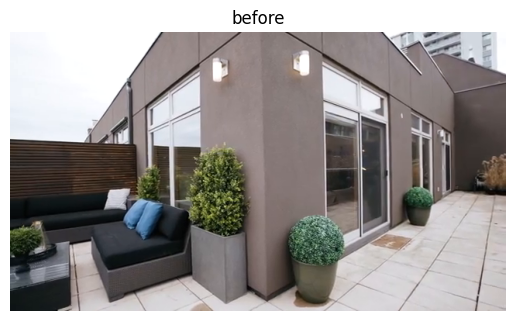

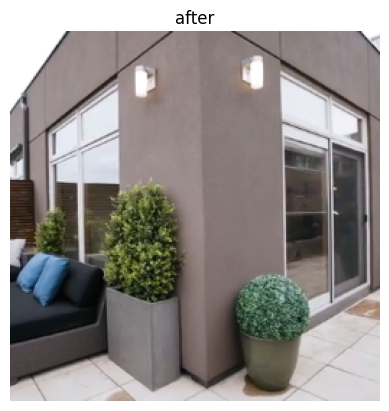

  1%|          | 1/182 [00:00<01:09,  2.62it/s]

torch.Size([1, 3, 256, 256])
All latents saved to: ../data_processed/realestate10k_latent/train/0c6c060f599465ed


In [ ]:
import os
from pathlib import Path
from tqdm import tqdm
import torch
from diffusers import AutoencoderKL
from PIL import Image
import numpy as np
import torch.nn.functional as F
import json
from typing import Any, Dict, List, Optional, Tuple, Union
import cv2


PATCH_SIZE = 256
VAE_SCALE = 8

def resize_crop_latent(image: torch.Tensor, K: np.ndarray, patch_size: int = 32, vae_scale=8):
    """
    Resize/crop a latent tensor (C,H,W) or (1,C,H,W) with subpixel accuracy.
    """
    if image.ndim == 3:
        image = image.unsqueeze(0)  # (1,C,H,W)

    _, _, h, w = image.shape
    scale = patch_size / min(h, w)
    new_w, new_h = w * scale, h * scale
    crop_x = (new_w - patch_size) / 2
    crop_y = (new_h - patch_size) / 2

    # Convert to normalized coordinates for affine_grid
    tx = -2 * crop_x / patch_size
    ty = -2 * crop_y / patch_size
    sx = scale * w / patch_size
    sy = scale * h / patch_size

    M = np.array([[sx, 0, tx],
        [0, sy, ty]], dtype=np.float32)
    theta = torch.tensor(M, dtype=torch.float32, device=image.device).unsqueeze(0)
    grid = F.affine_grid(theta, size=(1, image.shape[1], patch_size, patch_size), align_corners=False)
    cropped_resized = F.grid_sample(image, grid, mode='bilinear', align_corners=False)

    # Adjust K for scale/crop and latent scale
    K_scaled = K.copy()
    K_scaled[:2, :] *= scale / vae_scale
    K_scaled[0, 2] -= crop_x / vae_scale
    K_scaled[1, 2] -= crop_y / vae_scale

    return cropped_resized.squeeze(0), K_scaled


def resize_crop_with_subpixel_accuracy(
    image: np.ndarray, K: np.ndarray, patch_size: int
) -> Tuple[np.ndarray, np.ndarray]:
    """Resize and crop the image to have the smallest side equal to `patch_size`,
    while maintaining sub-pixel accuracy using a single warpAffine transformation.

    Args:
        image (np.ndarray): Input image.
        K (np.ndarray): Camera intrinsic matrix.
        patch_size (int): Target size of the smaller dimension.

    Returns:
        Tuple[np.ndarray, np.ndarray]: Resized and cropped image, updated intrinsic matrix.
    """
    h, w = image.shape[:2]
    scale = patch_size / min(h, w)

    # Compute the affine transformation matrix combining scaling and cropping
    new_w, new_h = w * scale, h * scale
    crop_x = (new_w - patch_size) / 2
    crop_y = (new_h - patch_size) / 2

    M = np.array([[scale, 0, -crop_x], [0, scale, -crop_y]], dtype=np.float32)

    # Apply affine transformation with sub-pixel accuracy
    is_downsampling = min(h, w) > patch_size
    interpolation = cv2.INTER_AREA if is_downsampling else cv2.INTER_CUBIC
    cropped_resized_image = cv2.warpAffine(
        image, M, (patch_size, patch_size), flags=interpolation
    )

    # Update intrinsic matrix K
    K_scaled = K.copy()
    K_scaled[:2, :] *= scale
    K_scaled[0, 2] -= crop_x
    K_scaled[1, 2] -= crop_y

    return cropped_resized_image, K_scaled

# Configuration
DTYPE = torch.float32
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Using device: {device}")

# Load VAE
vae = AutoencoderKL.from_pretrained(
    "black-forest-labs/FLUX.1-dev",
    subfolder="vae",
    torch_dtype=DTYPE
).to(device)
vae.eval()

# Input / output folders
src_dir = Path("../scratch/partial_datasets/realestate10k/train/0c6c060f599465ed/")
dst_dir = Path("../data_processed/realestate10k_latent/train/0c6c060f599465ed/")
dst_dir.mkdir(parents=True, exist_ok=True)

src_img_dir = Path.joinpath(src_dir,"images")

json_path = os.path.join(src_dir, "transforms.json")
with open(json_path, "r") as f:
    meta_info = json.load(f)

K = np.array([
    [meta_info["fl_x"], 0, meta_info["cx"]],
    [0, meta_info["fl_y"], meta_info["cy"]],
    [0, 0, 1],
], dtype=np.float32)

n_max = 1
n = 0

# Iterate over all PNG files
for img_path in tqdm(sorted(src_img_dir.glob("*.png"))):
    n += 1
    if (n > n_max):
        break
    # Load and preprocess
    # print(f"encoding {img_path}")
    img = Image.open(img_path).convert("RGB")
    img_tensor = torch.tensor(np.array(img), dtype=torch.float32)
    img_tensor = img_tensor / 255.0 * 2 - 1
    img_tensor = img_tensor.unsqueeze(0).permute(0, 3, 1, 2)    

    early_cand = img_tensor

    show_tensor(img_tensor,"before")     
    # torch.Size([1, 3, 360, 640])
    # img_tensor, K_scaled = resize_crop_latent(img_tensor, K, patch_size=PATCH_SIZE)
    img_tensor = img_tensor.permute(0, 2, 3, 1).squeeze(0)
    # torch.Size([360, 640, 3])
    img_tensor, K_scaled = resize_crop_with_subpixel_accuracy(img_tensor.numpy(), K, patch_size=PATCH_SIZE)

    img_tensor = torch.tensor(img_tensor).unsqueeze(0).permute(0, 3, 1, 2)    
    # torch.Size([1, 3, 256, 256])
    
    show_tensor(img_tensor,"after")    
    
    print(img_tensor.shape)
    # torch.Size([1, 3, 256, 256])
    
    # img_tensor = img_tensor.permute(0, 2, 3, 1)
    # print(img_tensor.shape)    
    # torch.Size([1, 256, 256, 3])

    img_tensor = img_tensor.to(device)


    # Encode
    with torch.no_grad():
        out = vae.encode(img_tensor)        
        z = out.latent_dist.mean  # deterministic latent

    # Save latent as .pt
    save_path = dst_dir / "images" / (img_path.stem + ".pt")
    torch.save(z.cpu(), "tmp.pt")



fx_new, fy_new = K_scaled[0, 0], K_scaled[1, 1]
cx_new, cy_new = K_scaled[0, 2], K_scaled[1, 2]
w_new = PATCH_SIZE // VAE_SCALE
h_new = PATCH_SIZE // VAE_SCALE

meta_info_latent = meta_info.copy()
meta_info_latent.update({
    "fl_x": float(fx_new),
    "fl_y": float(fy_new),
    "cx": float(cx_new),
    "cy": float(cy_new),
    "w": int(w_new),
    "h": int(h_new),
})
# latent_json_path = dst_dir / "transforms.json"
# with open(latent_json_path, "w") as f:
#     json.dump(meta_info_latent, f, indent=2)

print("All latents saved to:", dst_dir)
